# TP 5 : IA & Santé - Ambulance (RL) 🚑
(CORRECTION DÉTAILLÉE)

**Objectif :** Implémenter un agent Q-Learning complet.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random 
# ... Code Environnement (Voir resources TP ou Correction) ...
SIZE = 5; OBSTACLES = [(1,1), (1,2), (2,2), (3,1), (3,3)]; GOAL = (4,4)
def step(state, action): pass # Placeholder

## Implémentation du Q-Learning

Configuration:
  Grid size: 5x5
  Start: (0, 0)
  Goal: (4, 4)
  Obstacles: [(1, 1), (1, 2), (2, 2), (3, 1), (3, 3)]
  Episodes: 100

✓ Q-Table initialized for 20 positions

Entraînement en cours...
  Episode 20/100 ✓
  Episode 40/100 ✓
  Episode 60/100 ✓
  Episode 80/100 ✓
  Episode 100/100 ✓

✓ Entraînement terminé!



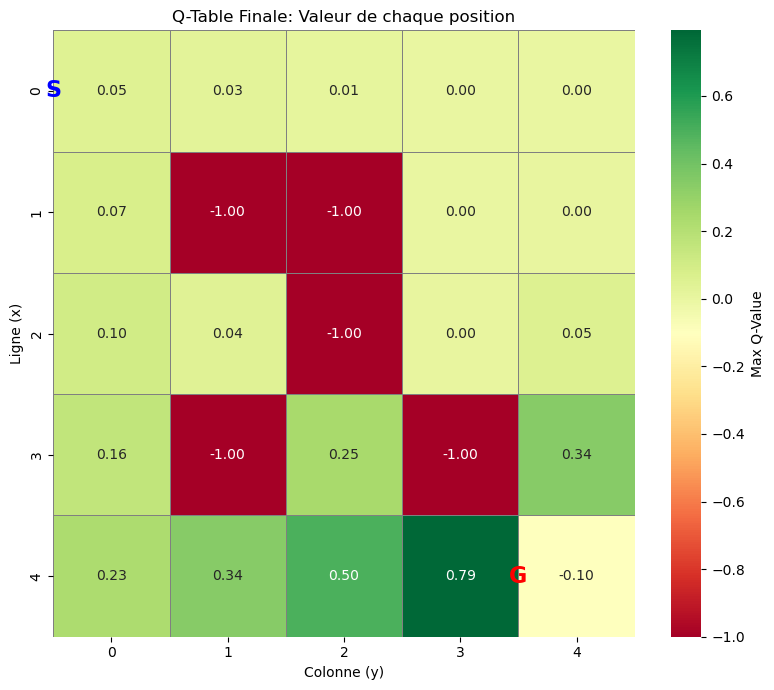

Interprétation:
  Vert = positions avec haute valeur (proche du but)
  Rouge = positions avec basse valeur (loin du but)
  Noir = obstacles
  S = départ (0,0)
  G = but (4,4)

Vérification du chemin appris:

  Chemin trouvé: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]
  Actions: ↓ Bas → ↓ Bas → ↓ Bas → ↓ Bas → → Droite → → Droite → → Droite → → Droite
  Nombre d'étapes: 8
  But atteint: True ✓


In [2]:
# === IMPLÉMENTATION COMPLÈTE DU Q-LEARNING ===

# Configuration des hyperparamètres
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.9
EPSILON = 0.9
NUM_EPISODES = 100
NUM_ACTIONS = 4  # Up=0, Down=1, Left=2, Right=3

print("Configuration:")
print(f"  Grid size: {SIZE}x{SIZE}")
print(f"  Start: (0, 0)")
print(f"  Goal: {GOAL}")
print(f"  Obstacles: {OBSTACLES}")
print(f"  Episodes: {NUM_EPISODES}\n")

# === ÉTAPE 1: Initialiser la Q-Table ===
# Une ligne pour chaque position, une colonne pour chaque action
q_table = {}
for i in range(SIZE):
    for j in range(SIZE):
        if (i, j) not in OBSTACLES:
            q_table[(i, j)] = [0.0] * NUM_ACTIONS

print(f"✓ Q-Table initialized for {len(q_table)} positions")

# === ÉTAPE 2: Fonction de sélection d'action (Epsilon-Greedy) ===
def choose_action(state):
    """
    Stratégie Epsilon-Greedy:
    - Avec probabilité epsilon: choisir une action aléatoire (exploration)
    - Sinon: choisir la meilleure action connue (exploitation)
    """
    if np.random.uniform() < EPSILON:
        return np.random.randint(NUM_ACTIONS)
    else:
        return np.argmax(q_table[state])

# === ÉTAPE 3: Fonction pour exécuter une action ===
def step(state, action):
    """Simuler l'environnement"""
    x, y = state
    
    # Déterminer la position suivante selon l'action
    if action == 0:  # Haut
        next_state = (x-1, y)
    elif action == 1:  # Bas
        next_state = (x+1, y)
    elif action == 2:  # Gauche
        next_state = (x, y-1)
    elif action == 3:  # Droite
        next_state = (x, y+1)
    else:
        next_state = state
    
    # Vérifier la validité
    if (next_state[0] < 0 or next_state[0] >= SIZE or 
        next_state[1] < 0 or next_state[1] >= SIZE or 
        next_state in OBSTACLES):
        # Invalide: rester sur place
        next_state = state
        reward = -0.5
    elif next_state == GOAL:
        # But atteint!
        reward = 1.0
    else:
        # Mouvement normal
        reward = 0.0
    
    is_terminal = next_state == GOAL
    return next_state, reward, is_terminal

# === ÉTAPE 4: Boucle d'entraînement (Q-Learning) ===
print("\nEntraînement en cours...")
for episode in range(NUM_EPISODES):
    state = (0, 0)  # Départ
    steps = 0
    
    # Continue jusqu'au but ou 50 étapes max
    while state != GOAL and steps < 50:
        # Choisir une action
        action = choose_action(state)
        
        # Exécuter l'action
        next_state, reward, is_terminal = step(state, action)
        
        # === FORMULE DU Q-LEARNING (BELLMAN) ===
        # Q(s,a) = Q(s,a) + α * (r + γ * max(Q(s',a')) - Q(s,a))
        # α = learning rate (combien on apprend de cette expérience)
        # γ = discount factor (importance du futur)
        # r = reward immédiate
        # max(Q(s',a')) = meilleure valeur future possible
        
        current_q = q_table[state][action]
        if next_state in q_table:
            max_next_q = max(q_table[next_state])
        else:
            max_next_q = 0
        
        new_q = current_q + LEARNING_RATE * (reward + DISCOUNT_FACTOR * max_next_q - current_q)
        q_table[state][action] = new_q
        
        state = next_state
        steps += 1
    
    if (episode + 1) % 20 == 0:
        print(f"  Episode {episode + 1}/{NUM_EPISODES} ✓")

print("\n✓ Entraînement terminé!\n")

# === ÉTAPE 5: Convertir Q-Table en matrice pour visualisation ===
q_values = np.zeros((SIZE, SIZE))
for (i, j), actions in q_table.items():
    q_values[i, j] = max(actions) if max(actions) > 0 else -0.1

# Marquer les obstacles
for obs in OBSTACLES:
    q_values[obs] = -1

# === ÉTAPE 6: Visualiser la Q-Table ===
plt.figure(figsize=(8, 7))
sns.heatmap(q_values, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Max Q-Value'},
            linewidths=0.5, linecolor='gray')
plt.title("Q-Table Finale: Valeur de chaque position")
plt.xlabel("Colonne (y)")
plt.ylabel("Ligne (x)")

# Ajouter des marqueurs
plt.text(0, 0.5, 'S', ha='center', va='center', color='blue', fontsize=16, fontweight='bold')
plt.text(GOAL[1], GOAL[0]+0.5, 'G', ha='center', va='center', color='red', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("Interprétation:")
print("  Vert = positions avec haute valeur (proche du but)")
print("  Rouge = positions avec basse valeur (loin du but)")
print("  Noir = obstacles")
print("  S = départ (0,0)")
print("  G = but (4,4)\n")

# === ÉTAPE 7: Vérifier le chemin appris ===
print("Vérification du chemin appris:\n")

state = (0, 0)
path = [state]
actions_taken = []

for step_num in range(50):
    # Prendre la meilleure action (exploitation pure, pas exploration)
    action = np.argmax(q_table[state])
    next_state, reward, is_terminal = step(state, action)
    
    action_names = ['↑ Haut', '↓ Bas', '← Gauche', '→ Droite']
    actions_taken.append(action_names[action])
    
    path.append(next_state)
    state = next_state
    
    if is_terminal:
        break

print(f"  Chemin trouvé: {path}")
print(f"  Actions: {' → '.join(actions_taken)}")
print(f"  Nombre d'étapes: {len(path)-1}")
print(f"  But atteint: {path[-1] == GOAL} ✓")